In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "darkgrid")
import joblib
import shap

from src.database.connection import get_connection
from src.training.data import split_dataset, split_features
from src.training.baselines import get_baseline_predictions
from src.training.evaluation import evaluate_models

import warnings
warnings.filterwarnings(
    "ignore",
    message = "pandas only supports SQLAlchemy connectable.*",
    category = UserWarning
)
warnings.filterwarnings(
    "ignore",
    message = ".*Falling back to prediction using DMatrix due to mismatched devices.*",
    category = UserWarning
)

#### LOAD DATA AND MODELS

In [2]:
conn = get_connection()

query = """
    SELECT 
        *
    FROM ndf;
"""

ndf = pd.read_sql(query, conn)
ndf["publish_time"] = pd.to_datetime(ndf["publish_time"], utc = True)
ndf["forecast_time"] = pd.to_datetime(ndf["forecast_time"], utc = True)

conn.close()

ndf.head()

,publish_time,forecast_time,forecast_demand_mw
0,2023-08-01 00:45:00+00:00,2023-08-01 01:00:00+00:00,17456.0
1,2023-08-01 00:45:00+00:00,2023-08-01 01:30:00+00:00,17211.0
2,2023-08-01 00:45:00+00:00,2023-08-01 02:00:00+00:00,17054.0
3,2023-08-01 00:45:00+00:00,2023-08-01 02:30:00+00:00,17097.0
4,2023-08-01 00:45:00+00:00,2023-08-01 03:00:00+00:00,16999.0


In [3]:
print(ndf.isna().sum(), "\n")
print(ndf.info(), "\n")
print(ndf.groupby("forecast_time").size().value_counts())

publish_time          0
forecast_time         0
forecast_demand_mw    0
dtype: int64 

<class 'pandas.DataFrame'>
RangeIndex: 123102 entries, 0 to 123101
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   publish_time        123102 non-null  datetime64[us, UTC]
 1   forecast_time       123102 non-null  datetime64[us, UTC]
 2   forecast_demand_mw  123102 non-null  float64            
dtypes: datetime64[us, UTC](2), float64(1)
memory usage: 2.8 MB
None 

2    24303
3    20372
1     6191
4     1791
5        5
Name: count, dtype: int64


In [4]:
data_path = "../data/dataset/modelling_dataset.parquet"
dataset = pd.read_parquet(data_path)

_, _, test_split = split_dataset(
    dataset = dataset,
    train_size = 0.7,
    validation_size = 0.15
)

X_test, y_test = split_features(test_split)

In [5]:
ridge = joblib.load("../models/optimised_ridge.joblib")
random_forest = joblib.load("../models/optimised_random_forest.joblib")
xgboost = joblib.load("../models/optimised_xgboost.joblib")

ridge_predictions = ridge.predict(X_test)
rf_predictions = random_forest.predict(X_test)
xgb_predictions = xgboost.predict(X_test)
baseline_predictions = get_baseline_predictions(test_split)

In [6]:
predictions = test_split[["reference_time", "target_time", "horizon", "target_demand"]].copy()

predictions["ridge"] = ridge_predictions
predictions["random_forest"] = rf_predictions
predictions["xgboost"] = xgb_predictions
predictions["baseline_30m"] = baseline_predictions["baseline_30m"]
predictions["baseline_24h"] = baseline_predictions["baseline_24h"]
predictions["baseline_7d"] = baseline_predictions["baseline_7d"]

predictions.sort_values(["reference_time", "horizon"]).head()

,reference_time,target_time,horizon,target_demand,ridge,random_forest,xgboost,baseline_30m,baseline_24h,baseline_7d
0,2026-02-18 12:00:00+00:00,2026-02-18 12:00:00+00:00,1,36670.0,33555.402027,35243.351623,33892.351562,35847.0,33586.0,33990.0
1,2026-02-18 12:00:00+00:00,2026-02-18 12:30:00+00:00,2,37058.0,33706.631276,35267.031784,33874.285156,35847.0,33958.0,33828.0
2,2026-02-18 12:00:00+00:00,2026-02-18 13:00:00+00:00,3,37285.0,34154.621500,35382.701381,33536.640625,35847.0,34640.0,34071.0
3,2026-02-18 12:00:00+00:00,2026-02-18 13:30:00+00:00,4,37533.0,34444.962012,35480.807037,33916.914062,35847.0,35332.0,34073.0
4,2026-02-18 12:00:00+00:00,2026-02-18 14:00:00+00:00,5,37724.0,34670.854365,35851.242054,35282.582031,35847.0,35895.0,33887.0


#### MODEL COMPARISON

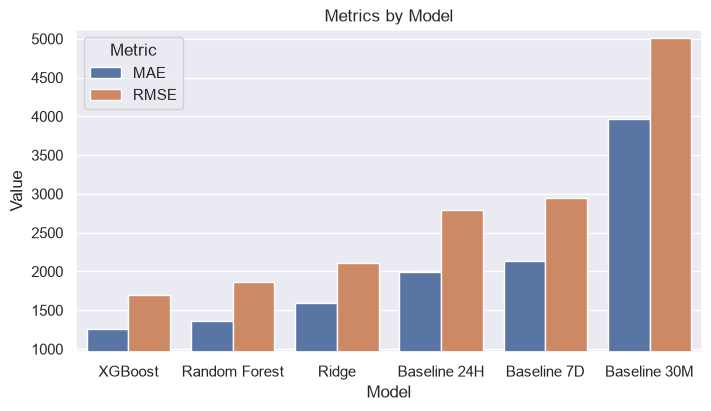

In [7]:
all_models = {
    "ridge": "Ridge",
    "random_forest": "Random Forest",
    "xgboost": "XGBoost",
    "baseline_30m": "Baseline 30M",
    "baseline_24h": "Baseline 24H",
    "baseline_7d": "Baseline 7D"
}

metrics_dict = {
    "RMSE": "rmse",
    "MAE": "mae"
}

results = []
for model in all_models.keys():
    metrics = evaluate_models(
        y_test = y_test,
        predictions = predictions[model]
    )

    for key, value in metrics_dict.items():
        results.append({
            "Model": all_models.get(model),
            "Metric": key,
            "Value": metrics[value]
        })

results = pd.DataFrame(results)

plt.figure(figsize = (7, 4), constrained_layout = True)

sns.barplot(
    data = results.sort_values(["Metric", "Value"]),
    x = "Model",
    y = "Value",
    hue = "Metric"
)

plt.title("Metrics by Model")

min_y = results.min()["Value"] - 300
max_y = results.max()["Value"] + 100
plt.ylim(min_y, max_y)

plt.show()

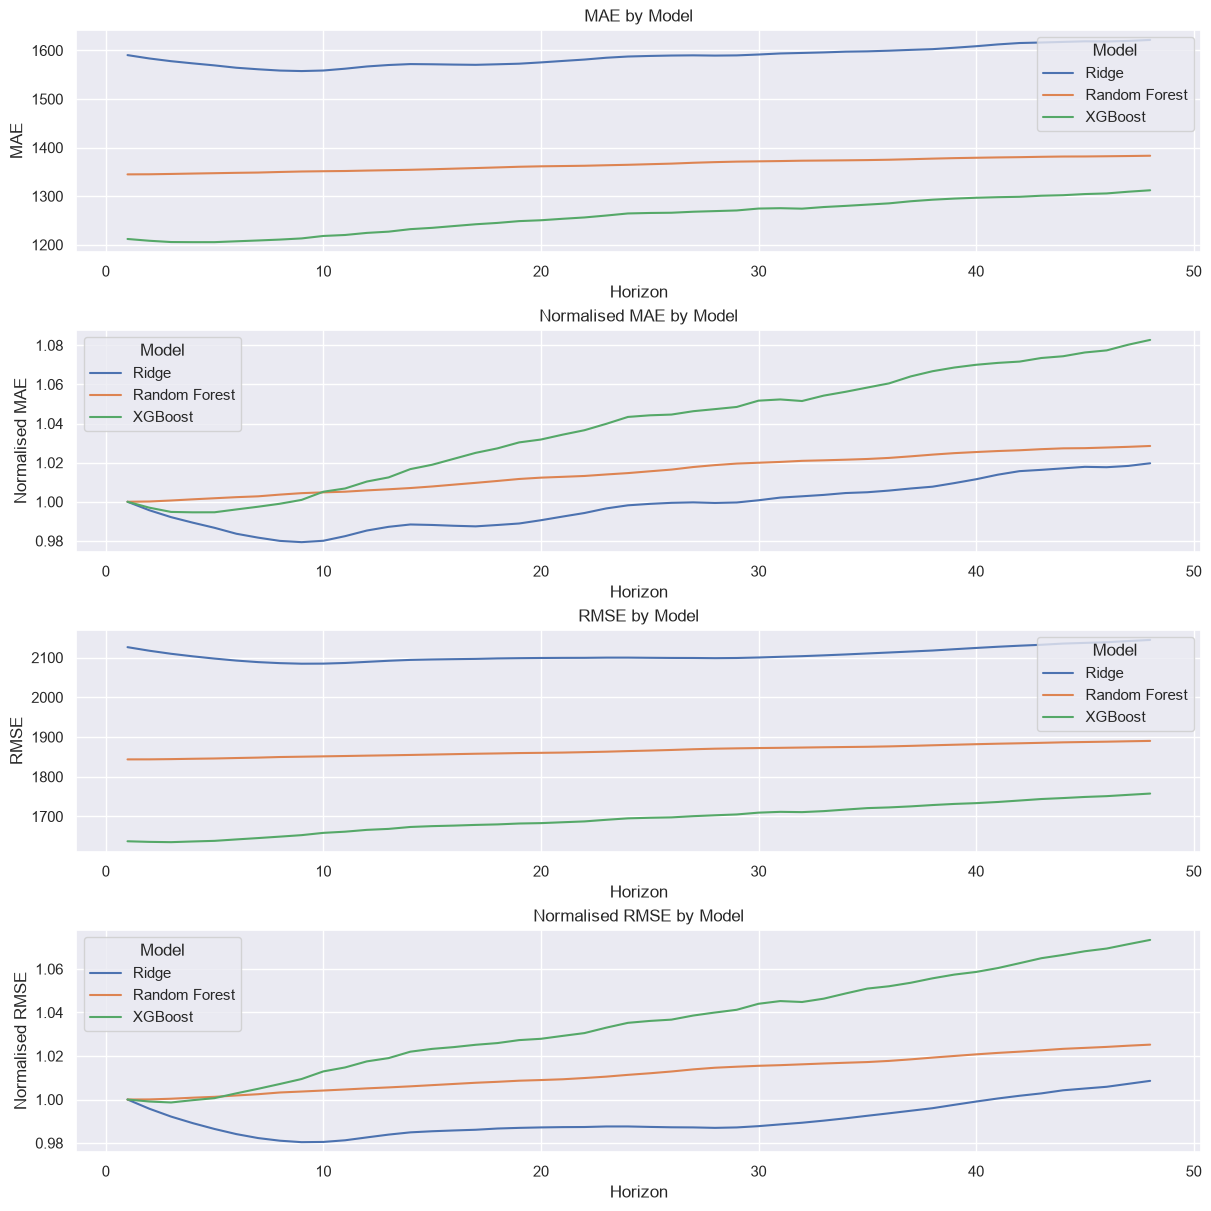

In [8]:
advanced_models = {
    "ridge": "Ridge",
    "random_forest": "Random Forest",
    "xgboost": "XGBoost"
}

horizon_results = []
for horizon in range(1, 49):
    horizon_data = predictions[predictions["horizon"] == horizon]

    for model in advanced_models.keys():
        metrics = evaluate_models(
            y_test = horizon_data["target_demand"],
            predictions = horizon_data[model]
        )

        horizon_results.append({
            "Horizon": horizon,
            "Model": advanced_models.get(model),
            "MAE": metrics["mae"],
            "RMSE": metrics["rmse"]
        })

horizon_results = pd.DataFrame(horizon_results)

first_mae = horizon_results.groupby("Model")["MAE"].transform("first")
first_rmse = horizon_results.groupby("Model")["RMSE"].transform("first")
horizon_results["Normalised MAE"] = horizon_results["MAE"] / first_mae
horizon_results["Normalised RMSE"] = horizon_results["RMSE"] / first_rmse

fig, axes = plt.subplots(4, 1, figsize = (12, 12), constrained_layout = True)

for metric, ax in zip(["MAE", "Normalised MAE", "RMSE", "Normalised RMSE"], axes):
    sns.lineplot(
        data = horizon_results,
        x = "Horizon",
        y = metric,
        hue = "Model",
        ax = ax
    )

    ax.set_title(f"{metric} by Model")

plt.show()

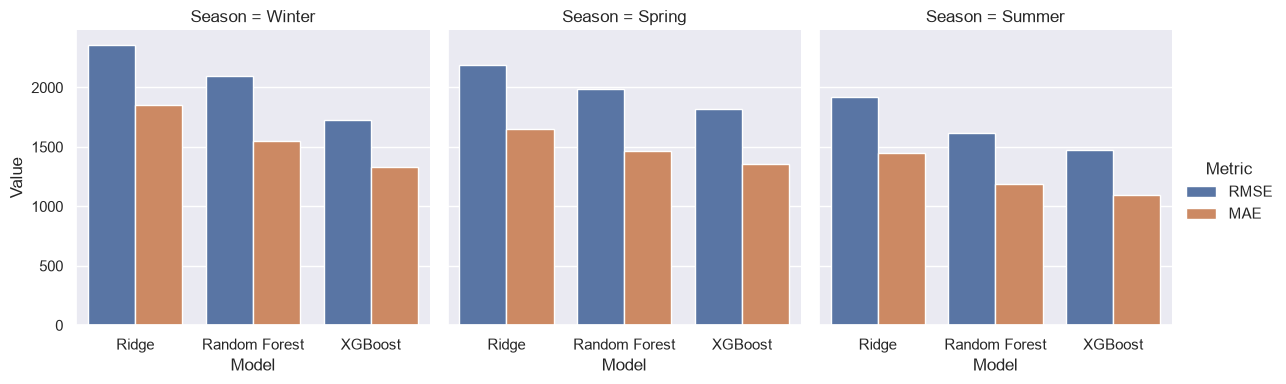

In [9]:
season_index = X_test.groupby("season").groups

seasons = ["Winter", "Spring", "Summer", "Autumn"]

season_results = []
for model in advanced_models.keys():
    for season in seasons:
        index = season_index.get(season)
        if index is None:
            continue

        metrics = evaluate_models(
            y_test = predictions.loc[index, "target_demand"],
            predictions = predictions.loc[index, model],
        )

        for key, value in metrics_dict.items():
            season_results.append({
                "Model": advanced_models.get(model),
                "Season": season,
                "Metric": key,
                "Value": metrics[value]
            })

season_results = pd.DataFrame(season_results)

sns.catplot(
    data = season_results,
    x = "Model",
    y = "Value",
    hue = "Metric",
    col = "Season",
    kind = "bar",
    height = 4,
    aspect = 1
)

plt.show()

In [10]:
for model in advanced_models:
    predictions[f"{model}_error"] = (predictions[model] - predictions["target_demand"]).abs()

predictions.nlargest(20, "ridge_error")[[
    "reference_time", 
    "target_time", 
    "horizon", 
    "target_demand", 
    "ridge", 
    "ridge_error"
]]

,reference_time,target_time,horizon,target_demand,ridge,ridge_error
89670,2026-03-29 10:00:00+00:00,2026-03-29 13:00:00+00:00,7,28710.0,18916.333459,9793.666541
89623,2026-03-29 09:30:00+00:00,2026-03-29 13:00:00+00:00,8,28710.0,19018.379650,9691.620350
89669,2026-03-29 10:00:00+00:00,2026-03-29 12:30:00+00:00,6,28298.0,18608.070260,9689.929740
89717,2026-03-29 10:30:00+00:00,2026-03-29 13:00:00+00:00,6,28710.0,19057.041338,9652.958662
89622,2026-03-29 09:30:00+00:00,2026-03-29 12:30:00+00:00,7,28298.0,18710.116451,9587.883549
89716,2026-03-29 10:30:00+00:00,2026-03-29 12:30:00+00:00,5,28298.0,18748.778139,9549.221861
89764,2026-03-29 11:00:00+00:00,2026-03-29 13:00:00+00:00,5,28710.0,19183.177156,9526.822844
89576,2026-03-29 09:00:00+00:00,2026-03-29 13:00:00+00:00,9,28710.0,19266.346832,9443.653168
89668,2026-03-29 10:00:00+00:00,2026-03-29 12:00:00+00:00,5,27940.0,18498.577702,9441.422298
89811,2026-03-29 11:30:00+00:00,2026-03-29 13:00:00+00:00,4,28710.0,19271.623289,9438.376711


In [11]:
predictions.nlargest(20, "random_forest_error")[[
    "reference_time", 
    "target_time", 
    "horizon", 
    "target_demand", 
    "random_forest", 
    "random_forest_error"
]]

,reference_time,target_time,horizon,target_demand,random_forest,random_forest_error
87790,2026-03-28 14:00:00+00:00,2026-03-29 13:00:00+00:00,47,28710.0,20204.196828,8505.803172
87837,2026-03-28 14:30:00+00:00,2026-03-29 13:00:00+00:00,46,28710.0,20223.964656,8486.035344
87743,2026-03-28 13:30:00+00:00,2026-03-29 13:00:00+00:00,48,28710.0,20237.175451,8472.824549
89905,2026-03-29 12:30:00+00:00,2026-03-29 13:00:00+00:00,2,28710.0,20250.140455,8459.859545
87884,2026-03-28 15:00:00+00:00,2026-03-29 13:00:00+00:00,45,28710.0,20252.773763,8457.226237
89811,2026-03-29 11:30:00+00:00,2026-03-29 13:00:00+00:00,4,28710.0,20260.173583,8449.826417
89717,2026-03-29 10:30:00+00:00,2026-03-29 13:00:00+00:00,6,28710.0,20268.977979,8441.022021
89764,2026-03-29 11:00:00+00:00,2026-03-29 13:00:00+00:00,5,28710.0,20274.883951,8435.116049
89858,2026-03-29 12:00:00+00:00,2026-03-29 13:00:00+00:00,3,28710.0,20275.462257,8434.537743
89952,2026-03-29 13:00:00+00:00,2026-03-29 13:00:00+00:00,1,28710.0,20279.666129,8430.333871


In [12]:
predictions.nlargest(20, "xgboost")[[
    "reference_time", 
    "target_time", 
    "horizon", 
    "target_demand", 
    "xgboost", 
    "xgboost_error"
]]

,reference_time,target_time,horizon,target_demand,xgboost,xgboost_error
294,2026-02-18 15:00:00+00:00,2026-02-18 18:00:00+00:00,7,40724.0,42381.304688,1657.304688
106,2026-02-18 13:00:00+00:00,2026-02-18 18:00:00+00:00,11,40724.0,42363.125000,1639.125000
59,2026-02-18 12:30:00+00:00,2026-02-18 18:00:00+00:00,12,40724.0,42362.421875,1638.421875
341,2026-02-18 15:30:00+00:00,2026-02-18 18:00:00+00:00,6,40724.0,42300.976562,1576.976562
388,2026-02-18 16:00:00+00:00,2026-02-18 18:00:00+00:00,5,40724.0,42300.976562,1576.976562
435,2026-02-18 16:30:00+00:00,2026-02-18 18:00:00+00:00,4,40724.0,42300.976562,1576.976562
482,2026-02-18 17:00:00+00:00,2026-02-18 18:00:00+00:00,3,40724.0,42299.011719,1575.011719
153,2026-02-18 13:30:00+00:00,2026-02-18 18:00:00+00:00,10,40724.0,42253.445312,1529.445312
200,2026-02-18 14:00:00+00:00,2026-02-18 18:00:00+00:00,9,40724.0,42249.132812,1525.132812
529,2026-02-18 17:30:00+00:00,2026-02-18 18:00:00+00:00,2,40724.0,42220.105469,1496.105469


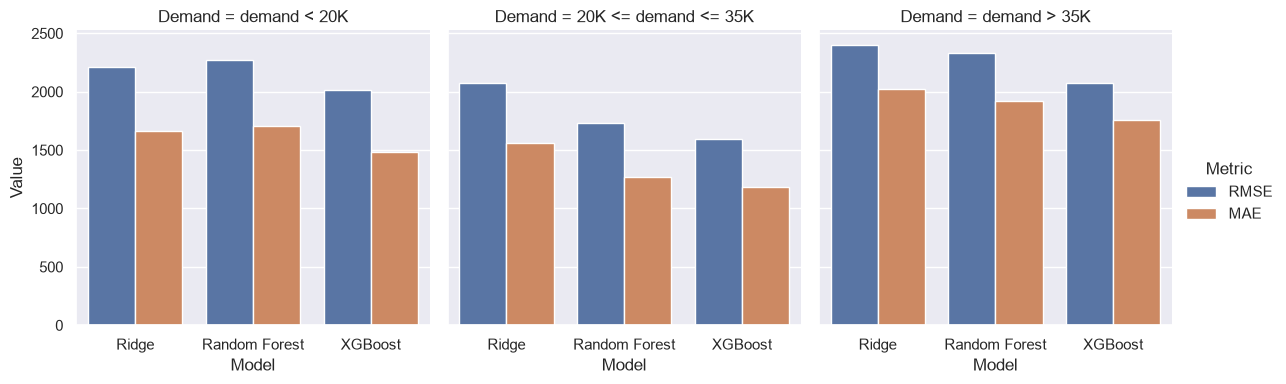

In [13]:
low_predictions = predictions[predictions["target_demand"] < 20000]
normal_predictions = predictions[
    (predictions["target_demand"] >= 20000) & (predictions["target_demand"] < 35000)
]
high_predictions = predictions[predictions["target_demand"] > 35000]

labels = ["demand < 20K", "20K <= demand <= 35K", "demand > 35K"]
datasets = [low_predictions, normal_predictions, high_predictions]

low_high_results = []
for model in advanced_models.keys():
    for label, dataset in zip(labels, datasets):
        metrics = evaluate_models(
            y_test = dataset["target_demand"],
            predictions = dataset[model],
            mape = True
        )

        for key, value in list(metrics_dict.items()) + [("MAPE", "mape")]:
            low_high_results.append({
                "Model": advanced_models.get(model),
                "Demand": label,
                "Metric": key,
                "Value": metrics[value]
            })

low_high_results = pd.DataFrame(low_high_results)

sns.catplot(
    data = low_high_results[low_high_results["Metric"] != "MAPE"],
    x = "Model",
    y = "Value",
    hue = "Metric",
    col = "Demand",
    kind = "bar",
    height = 4,
    aspect = 1
)

plt.show()

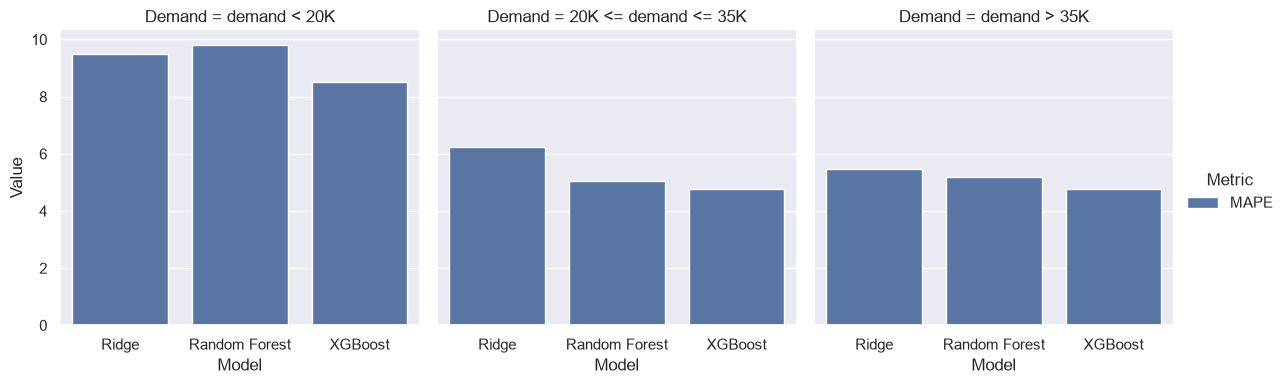

In [14]:
sns.catplot(
    data = low_high_results[low_high_results["Metric"] == "MAPE"],
    x = "Model",
    y = "Value",
    hue = "Metric",
    col = "Demand",
    kind = "bar",
    height = 4,
    aspect = 1
)

plt.show()

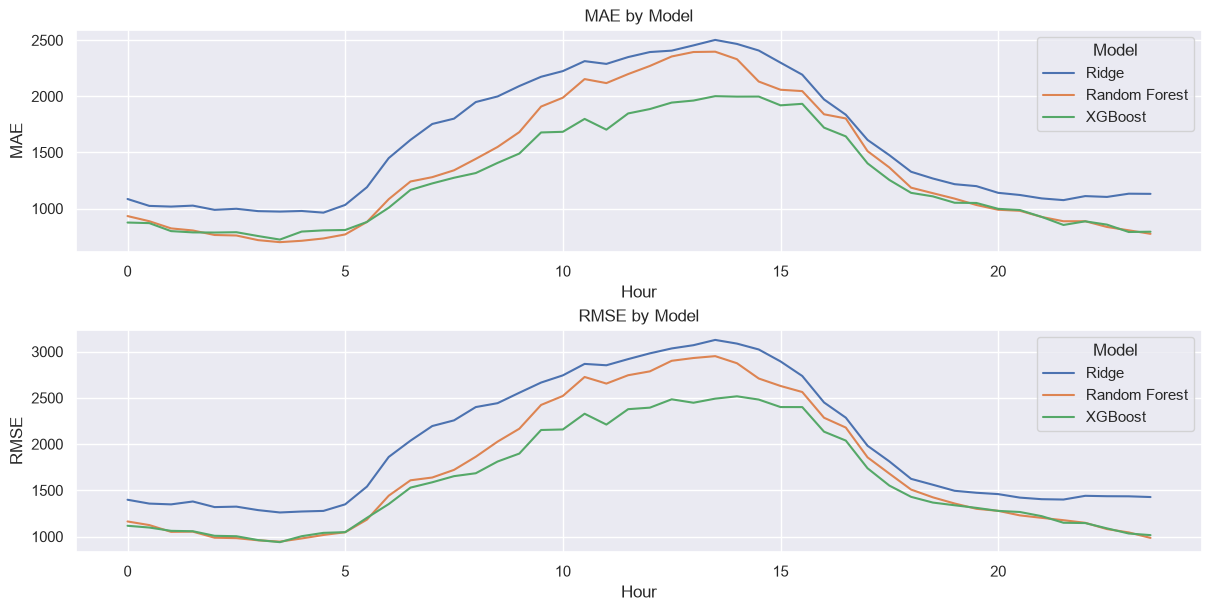

In [15]:
predictions["time_of_day"] = X_test["time_of_day"]

hour_results = []
for hour in np.arange(0, 24, 0.5):
    hour_data = predictions[predictions["time_of_day"] == hour]

    for model in advanced_models.keys():
        metrics = evaluate_models(
            y_test = hour_data["target_demand"],
            predictions = hour_data[model]
        )

        hour_results.append({
            "Hour": hour,
            "Model": advanced_models.get(model),
            "MAE": metrics["mae"],
            "RMSE": metrics["rmse"]
        })

hour_results = pd.DataFrame(hour_results)

fig, axes = plt.subplots(2, 1, figsize = (12, 6), constrained_layout = True)

for metric, ax in zip(["MAE", "RMSE"], axes):
    sns.lineplot(
        data = hour_results,
        x = "Hour",
        y = metric,
        hue = "Model",
        ax = ax
    )

    ax.set_title(f"{metric} by Model")

plt.show()

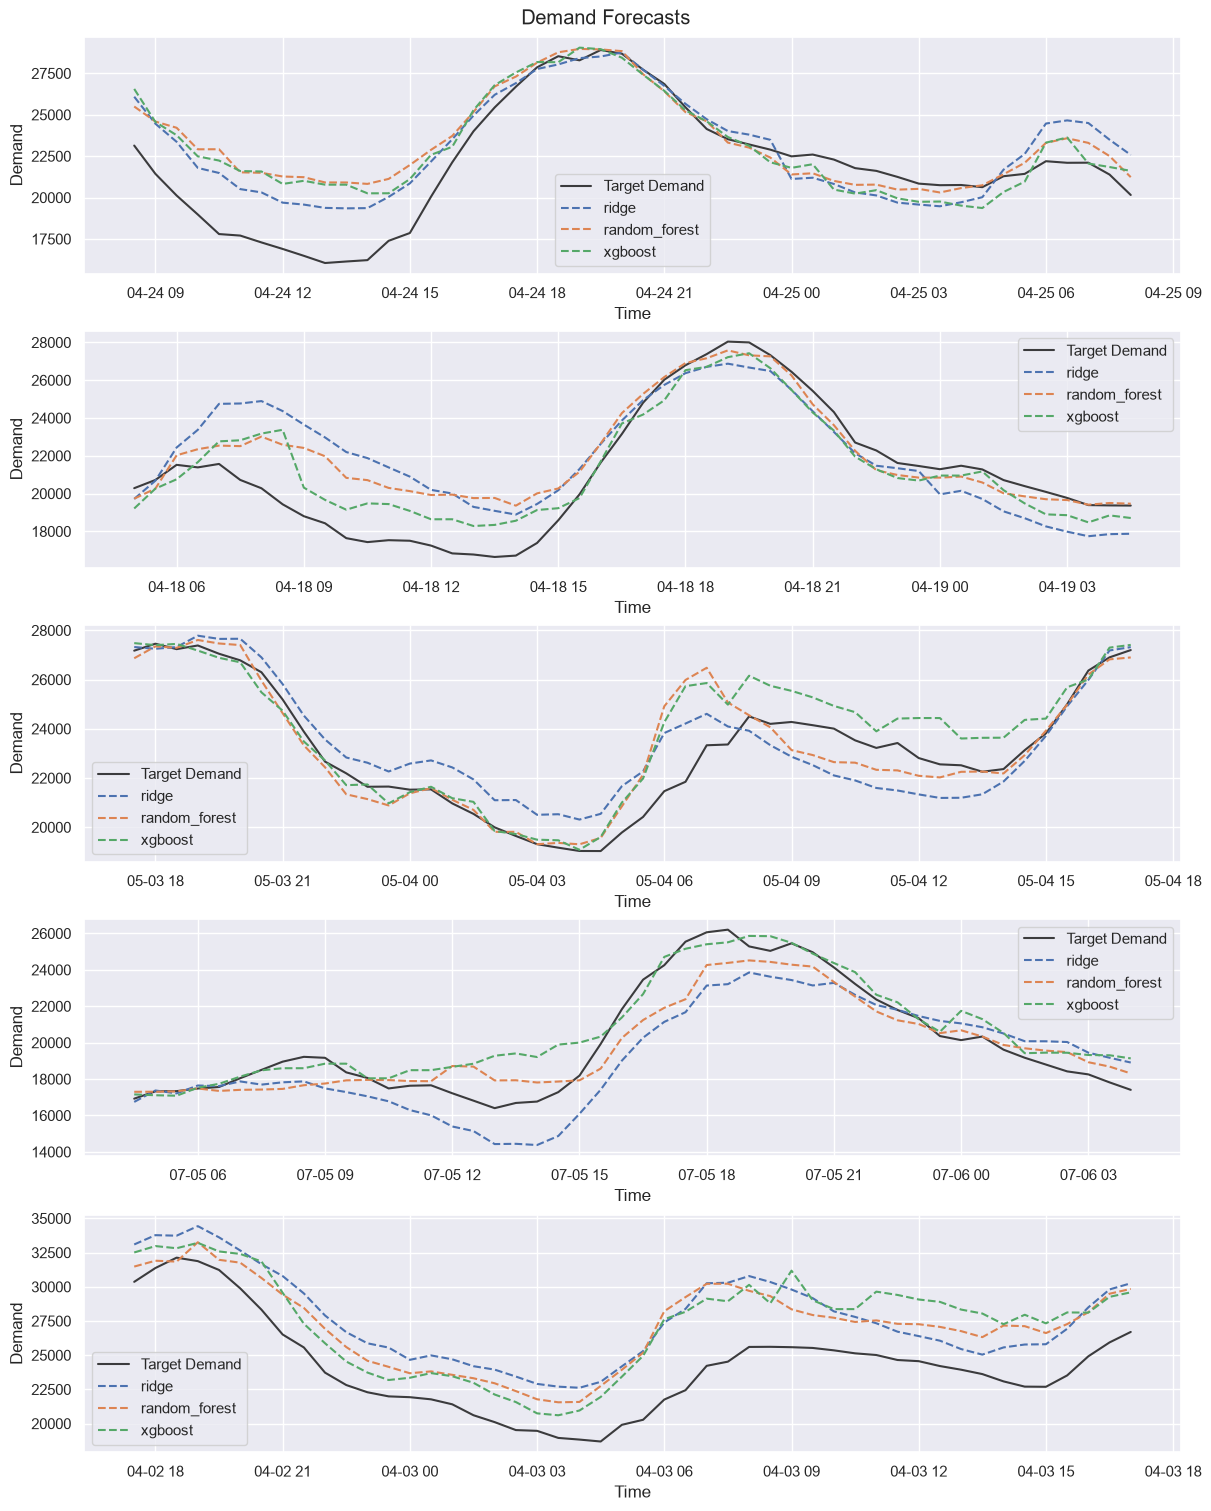

In [16]:
reference_times = predictions["reference_time"].drop_duplicates()
sample = reference_times.sample(5, random_state = 123)
random_forecasts = predictions[predictions["reference_time"].isin(sample)]

fig, axes = plt.subplots(5, 1, figsize = (12, 15), constrained_layout = True)
fig.suptitle("Demand Forecasts")

for time, ax in zip(sample, axes):
    data = predictions[predictions["reference_time"] == time]

    sns.lineplot(
        data = data,
        x = "target_time",
        y = "target_demand",
        ax = ax,
        label = "Target Demand",
        color = "black",
        alpha = 0.75
    )

    for model in advanced_models:
        sns.lineplot(
            data = data,
            x = "target_time",
            y = model,
            ax = ax,
            label = model,
            linestyle = "--"
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Demand")

plt.show()

#### NDF COMPARISON

In [17]:
ndf_compare = predictions[[
    "reference_time",
    "target_time",
    "horizon",
    "target_demand",
    "ridge",
    "random_forest",
    "xgboost"
]].copy()

ndf_compare = ndf_compare.merge(
    ndf,
    left_on = "target_time",
    right_on = "forecast_time",
    how = "left"
)

ndf_compare = ndf_compare[ndf_compare["publish_time"] <= ndf_compare["reference_time"]]

ndf_compare = ndf_compare.sort_values("publish_time").groupby(
    ["reference_time", "target_time", "horizon"], as_index = False
).tail(1).rename(columns = {
    "forecast_demand_mw": "ndf_prediction"
})

ndf_compare.head()

,reference_time,target_time,horizon,target_demand,ridge,random_forest,xgboost,publish_time,forecast_time,ndf_prediction
180,2026-02-18 12:30:00+00:00,2026-02-19 04:30:00+00:00,33,25283.0,25117.405009,25213.761005,24755.767578,2026-02-18 07:46:00+00:00,2026-02-19 04:30:00+00:00,25465.0
224,2026-02-18 13:00:00+00:00,2026-02-18 19:30:00+00:00,14,38574.0,39628.315934,39297.707352,39950.132812,2026-02-18 07:46:00+00:00,2026-02-18 19:30:00+00:00,39410.0
1488,2026-02-18 20:00:00+00:00,2026-02-19 00:00:00+00:00,9,27133.0,27741.847157,27573.019910,28205.375000,2026-02-18 07:46:00+00:00,2026-02-19 00:00:00+00:00,27370.0
1491,2026-02-18 20:00:00+00:00,2026-02-19 00:30:00+00:00,10,27884.0,28309.345744,28290.429624,28386.595703,2026-02-18 07:46:00+00:00,2026-02-19 00:30:00+00:00,28200.0
208,2026-02-18 13:00:00+00:00,2026-02-18 15:30:00+00:00,6,38215.0,37143.693416,38723.014847,39256.234375,2026-02-18 07:46:00+00:00,2026-02-18 15:30:00+00:00,37736.0


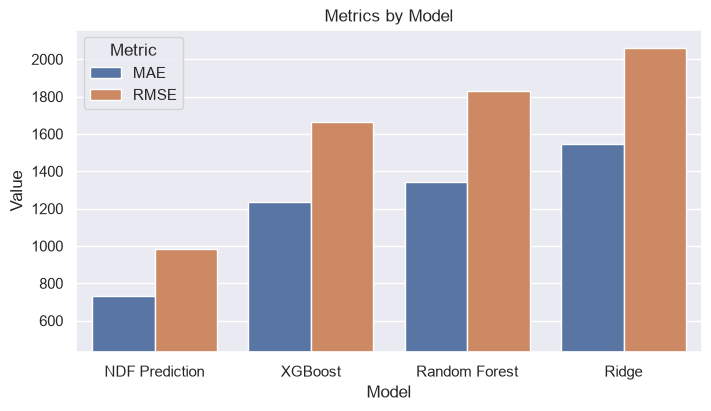

In [18]:
advanced_models_with_ndf = {
    "ridge": "Ridge",
    "random_forest": "Random Forest",
    "xgboost": "XGBoost",
    "ndf_prediction": "NDF Prediction"
}

ndf_results = []
for model in advanced_models_with_ndf.keys():
    metrics = evaluate_models(
        y_test = ndf_compare["target_demand"],
        predictions = ndf_compare[model]
    )

    for key, value in metrics_dict.items():
        ndf_results.append({
            "Model": advanced_models_with_ndf.get(model),
            "Metric": key,
            "Value": metrics[value]
        })

ndf_results = pd.DataFrame(ndf_results)

plt.figure(figsize = (7, 4), constrained_layout = True)

sns.barplot(
    data = ndf_results.sort_values(["Metric", "Value"]),
    x = "Model",
    y = "Value",
    hue = "Metric"
)

plt.title("Metrics by Model")

min_y = ndf_results.min()["Value"] - 300
max_y = ndf_results.max()["Value"] + 100
plt.ylim(min_y, max_y)

plt.show()

#### FEATURES - XGBOOST ONLY

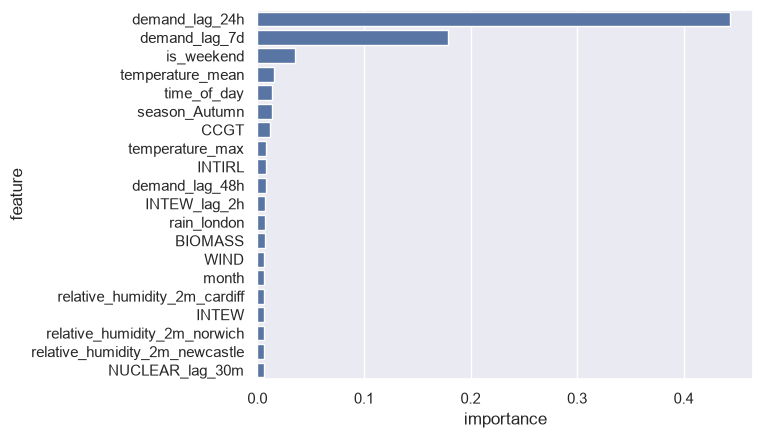

In [19]:
preprocessor = xgboost.named_steps["preprocessor"]
model = xgboost.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split("__")[1] for name in feature_names]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending = False).head(20)

sns.barplot(
    data = importance_df,
    x = "importance",
    y = "feature"
)

plt.show()

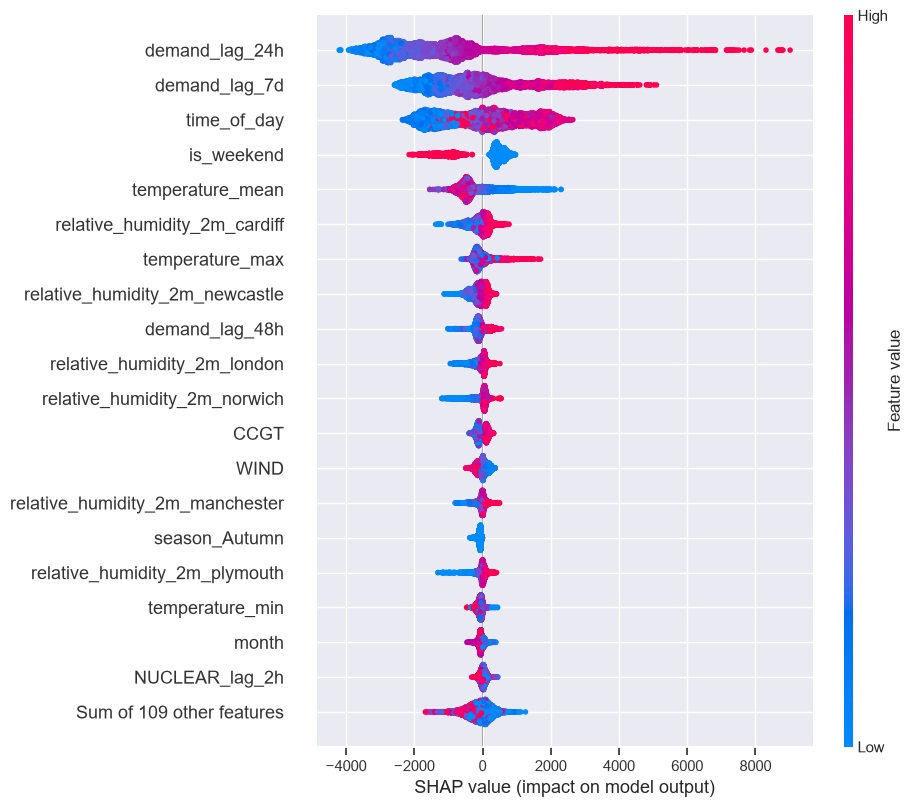

In [20]:
X_sample = X_test.sample(n = 10000, random_state = 123)
X_sample_transformed = preprocessor.transform(X_sample)
X_sample_transformed = pd.DataFrame(
    X_sample_transformed,
    columns = feature_names,
    index = X_sample.index
)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample_transformed)

shap.plots.beeswarm(
    shap_values,
    max_display = 20
)